# Epidemiological Model Assignment - Parameter exploration

## Functions taken from computer practical.

In [36]:
# 🟢 Setup and Required Libraries
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.integrate import odeint
import seaborn as sns
import jinja2

# Set plotting style
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
%matplotlib inline

print("All libraries imported successfully!")

All libraries imported successfully!


In [37]:
def sird_model(y, t, beta, gamma, mu):
    """
    SIRD model with death compartment

    TODO: Adapt the SIR model to include deaths

    Additional parameter:
    - mu: mortality rate

    New compartment:
    - D: Deaths
    """
    S, I, R, D = y  # Note: now 4 compartments
    N = S + I + R + D

    # Equations

    dSdt = -beta * S * I / N
    dIdt = beta * S * I / N - gamma * I - mu * I
    dRdt = gamma * I
    dDdt = mu * I

    return dSdt, dIdt, dRdt, dDdt

In [38]:
def run_sird_simulation(beta, gamma, mu, N=1000, I0=10, days=150, plot=False):


    S0 = N - I0
    R0 = 0
    D0 = 0
    y0 = [S0, I0, R0, D0]

    # Time points (same as before)
    # Note: days - 1 as the endpoint so that t[i] == i exactly
    t = np.linspace(0, days - 1, days)

    sol = odeint(sird_model, y0, t, args=(beta, gamma, mu))
    S, I, R, D = sol.T

    if plot:
      # 4 lines plots
        plt.figure(figsize=(10, 6))
        plt.plot(t, S, 'b-', label='Susceptible', linewidth=2)
        plt.plot(t, I, 'r-', label='Infectious', linewidth=2)
        plt.plot(t, R, 'g-', label='Recovered', linewidth=2)
        plt.plot(t, D, 'k-', label='Deaths', linewidth=2)

        plt.xlabel('Time (days)')
        plt.ylabel('Population')
        plt.title(f'SIRD Model: β={beta}, γ={gamma}, μ={mu}')
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.show()

    return t, S, I, R, D

---
## Part 1: Parameter analysis function.

In [39]:
def analyze_recovery_rates(beta, mu, N, I0, simulation_days, title):
    """
    Analyze epidemic outcomes for different recovery rates.

    Parameters:
    -----------
    beta : float
        Transmission rate
    mu : float
        Mortality rate
    N : int
        Total population
    I0 : int
        Initial infected individuals
    simulation_days : int
        Simulation duration in days

    Returns:
    --------
    pandas.DataFrame
        Results summary for each recovery rate
    """
    # Your implementation here
    gamma_values = [0.05, 0.1, 0.15, 0.2, 0.25]
    results = []
    fig, ax = plt.subplots(figsize=(10, 6))

    for i,gamma in enumerate(gamma_values):
        t, S, I, R, D = run_sird_simulation(beta, gamma, mu, N, I0, simulation_days)

        # Store results
        results.append({
            "Recovery Rate (γ)": gamma,
            "Peak Infected": np.max(I),
            "Peak Infected Day": np.argmax(I),
            "Total Deaths": D[-1],
            "R₀": beta / gamma
        })

        # Plot epidemic curve
        ax.plot(t, I, label=f'γ={gamma:.2f}')

    ax.set_xlabel('Time (days)')
    ax.set_ylabel('Number of Infectious Individuals')
    ax.set_title(f'Effect of Recovery Rate on Epidemic Dynamics - {title}')
    ax.legend(title='Recovery Rate (γ)', frameon=False)
    ax.grid(alpha=0.2)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    fig.tight_layout()

    df = pd.DataFrame(results)
    df = df.style.format({
        "Recovery Rate (γ)": "{:.2f}",
        "Peak Infected": "{:.0f}",
        "Peak Infected Day": "{:.0f}",
        "Total Deaths": "{:.0f}",
        "R₀": "{:.2f}"
    })

    return df, fig, ax



,Recovery Rate (γ),Peak Infected,Peak Infected Day,Total Deaths,R₀
0,0.05,566.018167,14,443.876822,12.0
1,0.10,426.974503,14,281.549178,6.0
2,0.15,320.775700,15,200.115248,4.0
3,0.20,235.258075,16,148.896143,3.0
4,0.25,167.578939,17,112.570926,2.4


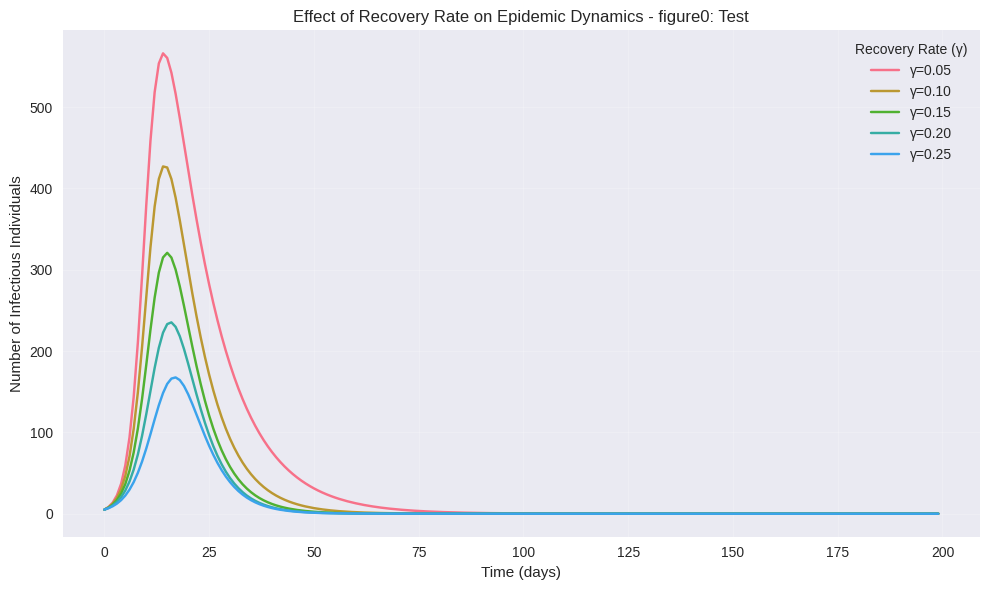

In [40]:
# Testing if analyze_recovery_rate() works.
dataFrameTest, figTest, axTest = analyze_recovery_rates(
    beta=0.6,
    mu=0.04,
    N=1000,
    I0=5,
    simulation_days=200,
    title="figure0: Test")
# Data frame for test:
dataFrameTest.data

## Part 2: Scenario comparison.

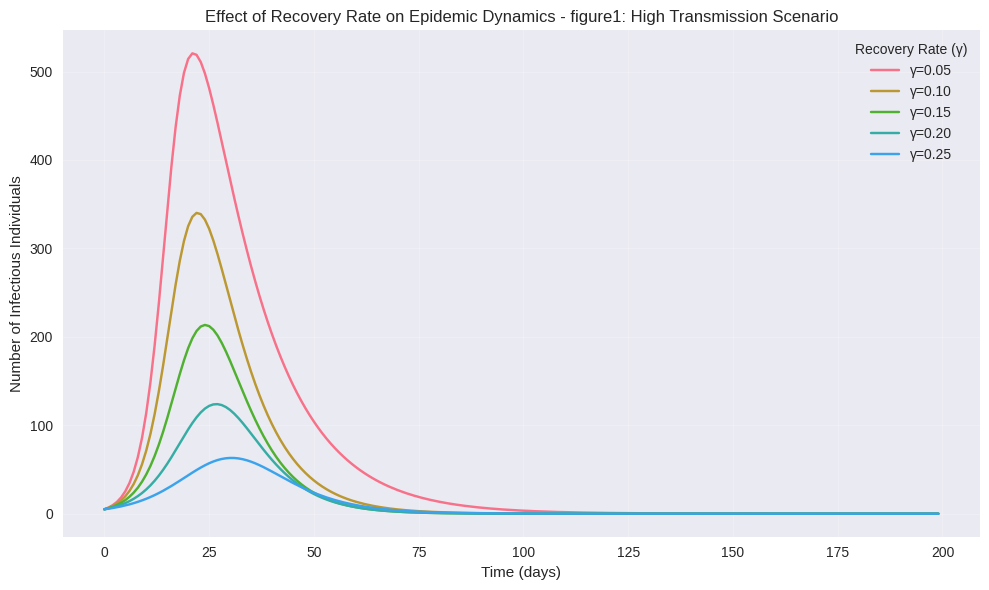

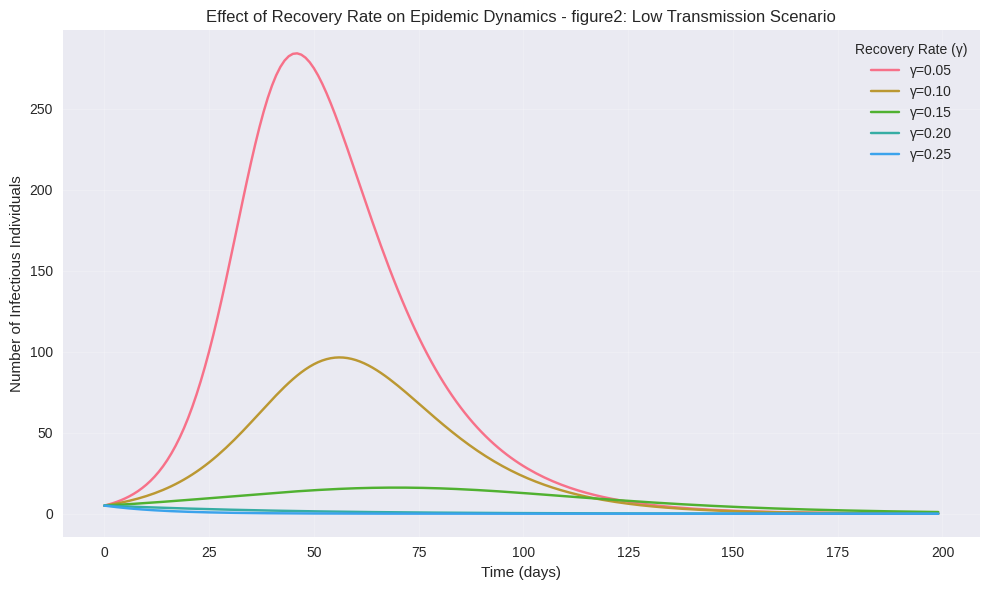

In [41]:
# High transmission scenario
df1, fig1, ax1 = analyze_recovery_rates(beta=0.4, mu=0.02, N=1000, I0=5, simulation_days=200, title="figure1: High Transmission Scenario")
# Low transmission scenario
df2, fig2, ax2 = analyze_recovery_rates(beta=0.2, mu=0.02, N=1000, I0=5, simulation_days=200, title="figure2: Low Transmission Scenario")

In [42]:
# Display the DataFrames
print("High Transmission Scenario Results:")
df1.data

High Transmission Scenario Results:


,Recovery Rate (γ),Peak Infected,Peak Infected Day,Total Deaths,R₀
0,0.05,520.582635,21,284.757361,8.000000
1,0.10,340.140583,22,159.892366,4.000000
2,0.15,213.465894,24,102.610885,2.666667
3,0.20,123.893909,27,67.423926,2.000000
4,0.25,63.051893,30,42.694003,1.600000


In [43]:
print("Low Transmission Scenario Results:")
df2.data

Low Transmission Scenario Results:


,Recovery Rate (γ),Peak Infected,Peak Infected Day,Total Deaths,R₀
0,0.05,284.284038,46,265.744527,4.000000
1,0.10,96.510865,56,113.172347,2.000000
2,0.15,16.119037,70,35.199664,1.333333
3,0.20,5.000000,0,3.995127,1.000000
4,0.25,5.000000,0,1.381814,0.800000


Conmparative Visualization of both scenarios


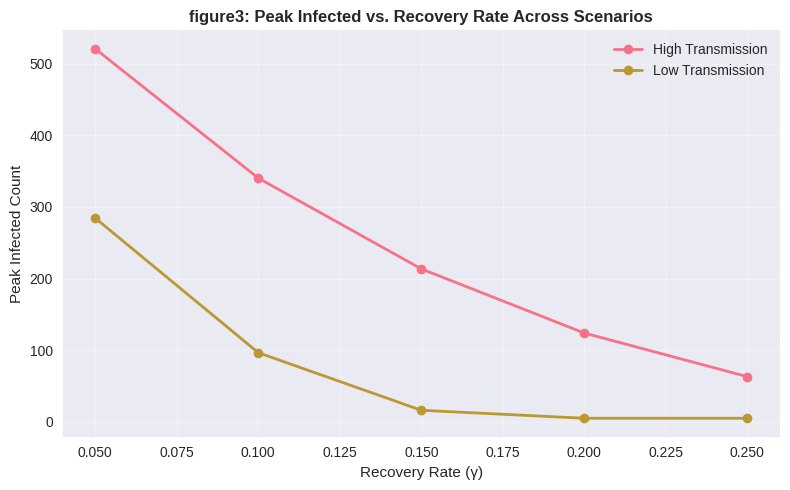

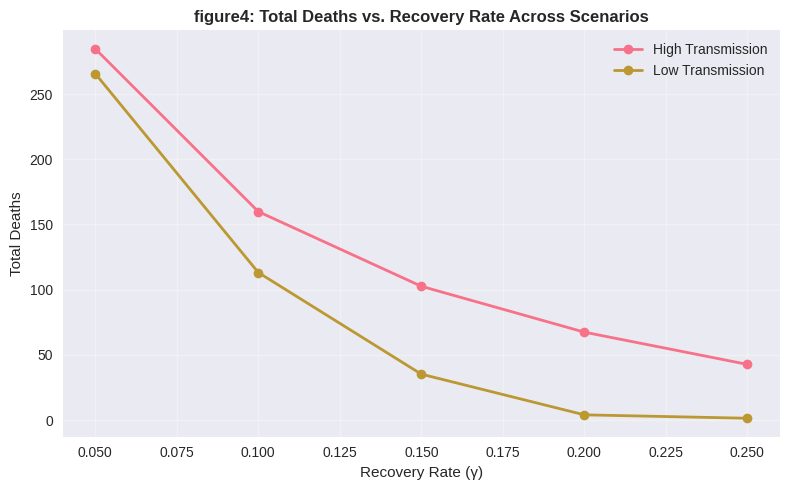

In [44]:
print("Conmparative Visualization of both scenarios")
data1 = df1.data.copy()
data1['Scenario'] = 'High Transmission'

data2 = df2.data.copy()
data2['Scenario'] = 'Low Transmission'

combined_df = pd.concat([data1, data2], ignore_index=True)

# Plot Peak Infected vs Recovery Rate for both scenarios
fig1_comp, ax1_comp = plt.subplots(figsize=(8, 5))

for scenario, group in combined_df.groupby('Scenario'):
    ax1_comp.plot(
            group["Recovery Rate (γ)"],
            group["Peak Infected"],
            marker="o",
            linewidth=2,
            label=scenario,
        )

ax1_comp.set_title(
    "figure3: Peak Infected vs. Recovery Rate Across Scenarios", fontweight="bold"
)
ax1_comp.set_xlabel("Recovery Rate (γ)")
ax1_comp.set_ylabel("Peak Infected Count")
ax1_comp.legend(frameon=False)
ax1_comp.grid(alpha=0.3)
ax1_comp.spines["top"].set_visible(False)
ax1_comp.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

# Plot Total Deaths vs Recovery Rate for both scenarios
fig2_comp, ax2_comp = plt.subplots(figsize=(8, 5))

for scenario, group in combined_df.groupby("Scenario"):
    ax2_comp.plot(
        group["Recovery Rate (γ)"],
        group["Total Deaths"],
        marker="o",
        linewidth=2,
        label=scenario,
    )

ax2_comp.set_title(
    "figure4: Total Deaths vs. Recovery Rate Across Scenarios", fontweight="bold"
)
ax2_comp.set_xlabel("Recovery Rate (γ)")
ax2_comp.set_ylabel("Total Deaths")
ax2_comp.legend(frameon=False)
ax2_comp.grid(alpha=0.3)
ax2_comp.spines["top"].set_visible(False)
ax2_comp.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()


### Transmission rate analysis

A high transmission scenario is more dangerous for public health because, at all tested recovery rates, the peak number of infected people is significantly higher than in the low transmission rate scenario. This gap is wide as the recovery rate is smaller, as we can see in the first plot, but even at the highest tested recovery rate, the high transmission scenario still has a higher number of infected individuals. It is also more dangerous for public health because the total number of deaths is always higher in the high transmission scenario, regardless of the recovery ate, as we can see in the second plot. This is because the higher transmission rate leads to more infections, which in turn leads to more deaths, even if the recovery rate is high. Therefore, controlling the transmission rate is crucial for public health, as it directly impacts both the peak number of infections and the total number of deaths.

## Part 3: Policy recommendations

### 3.1 Parameter impact analysis

#### Recovery rate vs infection peak

The higher the recovery rate, the lower the number of peak infections and total deaths, and shorter epidemic durations in both cases: low and high trasnmission rates.

Example for peak infections with high transmission rate: When the recovery rate goes from 0.05 to 0.10 the peak infected number goes from 520.5 to 340.1, which is a drastic change. In this case, when recovery rate goes from 0.20 to 0.25 the peak infections number goes from 123.8 to 63.0, which still counts as lower, but not as a higher change.

Example for peak infections with low transmission rate: When the recovery rate goes from 0.05 to 0.10 the peak infected number goes from 284.2 to 96.5, which is a drastic change as well. However, when the recovery rate goes from 0.20 to 0.25 there is no change in the peak infected numbers which is 5, because the number of people is low now.

Therefore, a higher recovery rate will lower the peak infections number as seen in figure1.


#### recovery rate vs death numbers


Example for total deaths with high transmission rate:

When the recovery rate goes from ***(0.05 to 0.10)*** the total death number goes from ***(284.7 to 159.89)***.

However, a change from ***(0.05 to 0.25)*** reduces total deaths number from ***(284.7 to 42.7)***, whcih is by ***85%*** compared to around ***43%***.

Example for total deaths with low transmission rate:

When the recovery rate goes from ***(0.05 to 0.25)*** the change is even more noticeable. The reduction goes to ***1.3*** total death (that means death reduction is around ***99%*** ).

Therefore, high recovery rate lowers total deaths despite the transmisssion rate. However the magnitude of this reduction at a specific recovery rate depends on the transmission rate at that specific recovery rate.


#### Recovery rate vs epidemic duration

Example for epidemic duration with high transmission rate: When the recovery rate goes from 0.05 to 0.25 the peak infection day goes from 21 to 30. It goes higher which gives time for healthcare institutions to prepare.

Example for total deaths with low transmission rate: When the recovery date goes from 0.05 to 0.25 the peak infection day goes from 46 to 0. In this case it goes lower, which means it is not an epidemic.


### 3.2 Intervention analysis

If recovery rate would be increased by ***50%***\, from scenerio A as the baseline the recovery rate that is ***0.05*** would go to ***0.075***. Then the total deaths would go from ***284.7*** to approximately ***222.25***\, because we know recovery rate for ***0.05*** has ***284.7*** deaths and recovery rate for ***0.10*** has ***159.8*** deaths we get:

$284.7 - (284.7 - 159.8) / 2 = 284.7 - 124.9 / 2 = 222.25$ deaths (approximately)

Deaths prevented = $284.7 - 222.2 = 62.5$

Therefore, we estimate (without simulating); if an intervention could increase recovery rate by ***50%***, total deaths would be around ***222.25*** meaning ***62.5*** deaths could be prevented compared to baseline model A (estimatedly).



### 3.3 Real-world application


In a large hospital there could be several problems, such as long wait times, which delay treatment and prolong recovery, crowded waiting rooms, which can increase the transmission rate, overworked staff, which reduces care quality and can mean worse outcomes, and insufficient or inefficient resources, which create limited access to specialized care, leading to slower recovery. Therefore, it is better to have a health system with multiple centers, each with different facilities for different severity levels. For example, testing centers for mild cases, primary care clinics for moderate cases and hospitals for severe cases. Additionally, there could be centers for different specialized treatments or temporary ones in case of an epidemic. By having these changes, the waiting time could lower, staff could be able to check on patients more and treatment would start earlier. This would, in conclusion, increase recovery rate by reducing the waiting time and improving care quality and reduce transmission rate by decreasing crowding.

In other words, the takeaway is; If we want lower infection peaks, reduce death numbers and shorten epidemic durations, then practices that increase the recovery rate are the most effective. A lower transmission rate could be more affective but that should be considered after optimizing recovery rate.